# GDELT GKG - Pipeline Simulation

> Test in [Google Colab](https://colab.research.google.com/)

Simulates the full Airflow pipeline end-to-end:
- Fetches GKG file URLs
- Downloads and parses each file
- Assigns a single dominant country to each article (discarding ties)
- Classifies articles into categories
- Aggregates country-level sentiment scores using log-weighted averaging with Bayesian shrinkage toward 0

The notebook serves as a prototype for the future pipeline, with the same constants and  functions intended for reuse in the Apache Airflow DAG.

Each section mirrors one task in the Airflow DAG so you can inspect the data at every stage.

---
## Section 1 - Setup

We import the libraries we need and define the constants and functions that every cell in this notebook depends on.

**#1** - Imports and constants


In [1]:
import io
import zipfile
from collections import Counter
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


# --- Constants ---

MASTER_URL      = 'http://data.gdeltproject.org/gdeltv2/masterfilelist-translation.txt'
MIN_WORD_COUNT  = 100   #  Exclude short articles during ingestion
MIN_ARTICLES    = 10    # minimum articles before a country enters PostgreSQL for country-level aggregation
CATEGORIES      = ['politics', 'economy', 'health', 'crime']

GKG_COLUMNS = [
    "GKGRECORDID",
    "DATE",
    "SOURCECOLLECTIONIDENTIFIER",
    "SOURCECOMMONNAME",
    "DOCUMENTIDENTIFIER",
    "COUNTS",
    "ENHANCEDCOUNTS",
    "THEMES",
    "ENHANCEDTHEMES",
    "LOCATIONS",
    "ENHANCEDLOCATIONS",
    "PERSONS",
    "ENHANCEDPERSONS",
    "ORGANIZATIONS",
    "ENHANCEDORGANIZATIONS",
    "TONE",
    "ENHANCEDDATES",
    "GCAM",
    "SHARINGIMAGE",
    "RELATEDIMAGES",
    "SOCIALIMAGEEMBEDS",
    "SOCIALVIDEOEMBEDS",
    "QUOTATIONS",
    "ALLNAMES",
    "AMOUNTS",
    "TRANSLATIONINFO",
    "EXTRASXML",
]


# --- Display Functions ---

def print_section_header(title):
    """
    Prints a formatted section header to separate output blocks.

    Args:
        title (str): The section title to display.
    """
    separator = '-' * 70
    print(f'\n{separator}')
    print(f'  {title}')
    print(f'{separator}')

print('Setup complete.')

Setup complete.


**#2** - Field parsers and article classifier functions

In [2]:
# --- Tone Field ---

TONE_FIELDS = [
    "tone",
    "positive_score",
    "negative_score",
    "polarity",
    "activity_reference_density",
    "self_group_reference_density",
    "word_count",
]


def parse_tone(raw_string: str | None) -> dict | None:
    """
    Parses the GKG Tone comma-separated field into a dictionary.

    Args:
        raw_string (str | None): Raw Tone string from a GKG record.

    Returns:
        dict | None: Dictionary with tone sub-fields, or None on parse failure.
    """
    if not raw_string or not isinstance(raw_string, str):
        return None

    parts = raw_string.split(",")
    if len(parts) != 7:
        return None

    try:
        numeric_values = [float(part) for part in parts[:6]] + [int(parts[6])]
    except ValueError:
        return None

    return dict(zip(TONE_FIELDS, numeric_values))


# --- Location Field ---

# LOCATION_FIELDS = [
#     "location_type",
#     "location_fullname",
#     "location_country_code",
#     "location_adm1_code",
#     "location_adm2_code",
#     "location_latitude",
#     "location_longitude",
#     "location_feature_id",
# ]

def parse_locations(raw_string: str | None) -> list[dict]:
    """
    Parses the GKG Locations semicolon-separated field into a list of location dicts.

    Args:
        raw_string (str | None): Raw Locations string from a GKG record.

    Returns:
        list[dict]: List of location dictionaries, empty on failure or missing data.
    """
    if not raw_string or not isinstance(raw_string, str):
        return []

    all_locations = []
    for raw_entry in raw_string.split(";"):
        entry = raw_entry.strip()
        if not entry:
            continue

        parts = entry.split("#")
        if len(parts) < 8:
            continue

        # Strip the trailing feature_id sub-field (after the last comma in parts[-1])
        parts[-1] = parts[-1].split(",")[0]

        try:
            all_locations.append({
                "location_type":         parts[0],
                "location_fullname":     parts[1],
                "location_country_code": parts[2],
                "location_adm1_code":    parts[3],
                "location_adm2_code":    parts[4],
                "location_latitude":     float(parts[5]) if parts[5] else None,
                "location_longitude":    float(parts[6]) if parts[6] else None,
                "location_feature_id":   parts[7] if len(parts) > 7 else "",
            })
        except (ValueError, IndexError):
            continue

    return all_locations


# --- Enhanced Field (Themes, Persons, Organizations) ---

def parse_enhanced_field(raw_string: str | None) -> list[tuple[str, int]]:
    """
    Parses any GKG enhanced semicolon-separated field into (value, character_offset) tuples.

    Args:
        raw_string (str | None): Raw enhanced field string from a GKG record.

    Returns:
        list[tuple[str, int]]: List of (value, offset) pairs, empty on failure.
    """
    if not raw_string or not isinstance(raw_string, str):
        return []

    parsed_entries = []
    for raw_entry in raw_string.split(";"):
        entry = raw_entry.strip()
        if "," not in entry:
            continue

        value, _, offset_string = entry.rpartition(",")
        try:
            parsed_entries.append((value, int(offset_string)))
        except ValueError:
            continue

    return parsed_entries


# --- Country Assignment ---

def primary_countries(enhancedlocations_raw: str | None) -> list[str]:
    """
    Returns a list of FIPS country codes that best represent an article's coverage.

    Rules:
      1. Count all location mentions regardless of location type.
      2. Return all countries tied at the maximum mention count (sorted).
      3. Return empty list if no location data exists.

    Args:
        enhancedlocations_raw (str | None): Raw Locations field.

    Returns:
        list[str]: Sorted list of FIPS country codes (may be empty).
    """
    all_locations = parse_locations(enhancedlocations_raw)
    if not all_locations:
        return []

    mention_counts = Counter(
        location_entry["location_country_code"]
        for location_entry in all_locations
        if location_entry["location_country_code"]
    )
    if not mention_counts:
        return []

    maximum_count = mention_counts.most_common(1)[0][1]
    return sorted(
        country_code
        for country_code, mention_count in mention_counts.items()
        if mention_count == maximum_count
    )


# --- Article Classifier ---

THEME_CATEGORIES = {
    "politics": [
        "GOVERNMENT", "DIPLOMACY", "POLITIC", "ELECTION",
        "DEMOCRA", "DICTAT", "GOVERNANCE", "CORRUPT", "LEGISLAT",
    ],
    "economy": [
        "ECON", "FINANC", "MARKET", "BUSINESS", "TAXES", "TAXATION",
        "INFLATION", "ENTERPRISE", "BANK", "COMMODI",
    ],
    "health": [
        "HEALTH", "DISEASE", "MEDICAL", "SANITA", "PHARMA",
        "PANDEMIC", "VACCINATION", "IMMUNIZATIONS", "DIABETES", "POISON",
    ],
    "crime": [
        "CRIME", "CRIMINAL", "INVESTIGATION", "TERROR", "KIDNAP",
        "SMUGGLING", "TRAFFICKING", "ASSASSINATION", "GENOCIDE",
        "VIOLEN", "RAPE", "FRAUD", "TORTURE",
    ],
}

CATEGORY_MINIMUM_PERCENTAGE  = 50.0
CATEGORY_MINIMUM_WINNING_GAP = 30.0
THEME_MINIMUM_HITS = {
    "crime":    3,
    "health":   3,
    "politics": 3,
    "economy":  3,
}


def get_matching_categories_for_theme(theme: str) -> list[str]:
    """
    Returns all categories whose prefix patterns match any token in the theme string.

    Args:
        theme (str): A single GKG theme string (e.g. "WB_HEALTH_PANDEMIC").

    Returns:
        list[str]: Category names that match the theme's tokens.
    """
    tokens = theme.upper().split("_")
    matching_categories = []
    for category, patterns in THEME_CATEGORIES.items():
        for token in tokens:
            for pattern in patterns:
                if token.startswith(pattern):
                    matching_categories.append(category)
                    break
            else:
                continue
            break
    return matching_categories


def classify_article_category_by_theme(enhancedthemes_raw: str | None) -> str | None:
    """
    Classifies an article into a category using prefix matching on ENHANCEDTHEMES.

    Rules:
      - The winning category must have > CATEGORY_MINIMUM_PERCENTAGE % of all matched hits.
      - The winning category must lead the runner-up by > CATEGORY_MINIMUM_WINNING_GAP percentage points.
      - The winning category must have >= THEME_MINIMUM_HITS[category] hits.

    Args:
        enhancedthemes_raw (str | None): Raw ENHANCEDTHEMES field from a GKG record.

    Returns:
        str | None: Category name ('politics', 'economy', 'health', 'crime'), or None.
    """
    theme_entries = parse_enhanced_field(enhancedthemes_raw)
    if not theme_entries:
        return None

    category_scores = {}
    for theme, _ in theme_entries:
        for category in get_matching_categories_for_theme(theme):
            category_scores[category] = category_scores.get(category, 0) + 1

    if not category_scores:
        return None

    category_scores = {
        category: score
        for category, score in category_scores.items()
        if score >= THEME_MINIMUM_HITS.get(category, 1)
    }
    if not category_scores:
        return None

    total_hits = sum(category_scores.values())
    sorted_percentages = sorted(
        (score / total_hits * 100 for score in category_scores.values()),
        reverse=True,
    )
    winner_percentage    = sorted_percentages[0]
    runner_up_percentage = sorted_percentages[1] if len(sorted_percentages) > 1 else 0.0

    if winner_percentage <= CATEGORY_MINIMUM_PERCENTAGE:
        return None
    if (winner_percentage - runner_up_percentage) <= CATEGORY_MINIMUM_WINNING_GAP:
        return None

    return max(category_scores, key=category_scores.get)

print('Parser and classifier functions loaded.')

Parser and classifier functions loaded.


---
## Section 2 - Fetch

This mirrors the `fetch_yesterday_urls` Airflow task.

We download the GDELT master file list and pull out the URLs for our target date.

**#3** - Fetch the file list for the target date

Change `TARGET_DATE` to run the simulation on a different day.

In [3]:
TARGET_DATE = date.today() - timedelta(days=1)
date_prefix = TARGET_DATE.strftime('%Y%m%d')

print(f'Target date : {TARGET_DATE}')
print('Fetching master file list...')

master_response = requests.get(MASTER_URL, timeout=60)
master_response.raise_for_status()

all_urls = [
    line.strip().split()[-1]
    for line in master_response.text.strip().splitlines()
    if line.strip().endswith('.gkg.csv.zip') and date_prefix in line
]

print(f'Found {len(all_urls)} GKG translation files for {TARGET_DATE}')


Target date : 2026-06-01 00:00:00
Fetching master file list...
Found 96 GKG translation files for 2026-06-01 00:00:00


---
## Section 3 - Ingest

This section mirrors the `ingest_all_files` Airflow task.

For each GKG file, the pipeline downloads the ZIP archive, extracts the CSV, and performs the following transformations:

- Parse the TONE field into numeric columns
- Filter out articles below the `MIN_WORD_COUNT` threshold
- Assign primary country codes from location mentions
- Classify each article into a news category

In the real Airflow pipeline, the transformed data is written to Parquet files. In this Google Colab notebook, the results are kept in memory.

In [4]:
def has_country_codes(value):
    """
    Returns True if the value is a non-empty list-like.

    Args:
        value: The primary_country_codes value for one row.

    Returns:
        bool: True if the article has at least one assigned country.
    """
    return value is not None and hasattr(value, '__len__') and len(value) > 0


all_parsed_frames = []
error_count       = 0
total_files       = len(all_urls)

for file_index, url in enumerate(all_urls, start=1):
    try:
        file_response = requests.get(url, timeout=300, stream=True)
        file_response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(file_response.content)) as zip_archive:
            csv_filename = next(
                name for name in zip_archive.namelist()
                if name.lower().endswith('.csv')
            )
            with zip_archive.open(csv_filename) as csv_file:
                raw_file_dataframe = pd.read_csv(
                    csv_file,
                    sep='\t',
                    header=None,
                    names=GKG_COLUMNS,
                    dtype=str,
                    encoding='latin-1',
                    on_bad_lines='warn',
                )

        tone_parsed  = raw_file_dataframe['TONE'].apply(parse_tone)
        tone_columns = pd.json_normalize(tone_parsed)
        file_dataframe = pd.concat(
            [raw_file_dataframe.drop(columns=['TONE']), tone_columns], axis=1
        )

        file_dataframe = file_dataframe[
            file_dataframe['word_count'].notna()
            & (file_dataframe['word_count'] >= MIN_WORD_COUNT)
        ]
        file_dataframe['primary_country_codes'] = file_dataframe['ENHANCEDLOCATIONS'].apply(
            primary_countries
        )
        file_dataframe['article_category'] = file_dataframe['ENHANCEDTHEMES'].apply(
            classify_article_category_by_theme
        )
        keep_cols = [
            'tone',
            'word_count',
            'primary_country_codes',
            'article_category',
            'DATE',
            'SOURCECOMMONNAME',
            'DOCUMENTIDENTIFIER',
            'ENHANCEDLOCATIONS',
            'ENHANCEDTHEMES',
        ]
        file_dataframe = file_dataframe[[c for c in keep_cols if c in file_dataframe.columns]]
        all_parsed_frames.append(file_dataframe)

        if file_index % 10 == 0 or file_index == total_files:
            print(f'  [{file_index}/{total_files}] loaded')

    except Exception as download_error:
        error_count += 1
        print(f'  ERROR [{file_index}] {url}: {download_error}')

full_day_dataframe = pd.concat(all_parsed_frames, ignore_index=True)
total_ingested     = len(full_day_dataframe)

print(f'\nIngest complete')
print(f'  Files loaded             : {total_files - error_count} / {total_files}')
print(f'  Download errors          : {error_count}')
print(f'  Articles after filtering : {total_ingested:,}')

  [10/96] loaded
  [20/96] loaded
  [30/96] loaded
  [40/96] loaded
  [50/96] loaded
  [60/96] loaded
  [70/96] loaded
  [80/96] loaded
  [90/96] loaded
  [96/96] loaded

Ingest complete
  Files loaded             : 96 / 96
  Download errors          : 0
  Articles after filtering : 200,545


---
## Section 4 - Aggregate

This section mirrors the `aggregate_and_write_postgres` Airflow task.

The pipeline computes a tone score for each country using the following steps:

- Discard articles where two or more countries are tied for the highest mention count
- Compute a log-weighted average tone using `log(word_count)` as the article weight
- Apply Bayesian shrinkage to shrink country-level tone scores toward neutral (0).

**#5** - Assign one country per article (Discard ties)

Articles are assigned to a country only when there is a single, clear winner in the `primary_country_codes` list. Any articles with tied mention counts are discarded and excluded from all scores and sidebars.

In [5]:
def is_single_country(codes):
    return hasattr(codes, '__len__') and len(codes) == 1

def extract_single_country(codes):
    return codes[0]

ready_dataframe = full_day_dataframe[
    full_day_dataframe['tone'].notna()
    & full_day_dataframe['word_count'].notna()
    & (full_day_dataframe['word_count'] > 0)
    & full_day_dataframe['primary_country_codes'].apply(has_country_codes)
].copy()

# Discard ties: only keep articles where exactly one country is dominant
single_country_mask = ready_dataframe['primary_country_codes'].apply(is_single_country)
articles_with_ties    = (~single_country_mask).sum()
exploded_dataframe    = ready_dataframe[single_country_mask].copy()
exploded_dataframe['primary_country_code'] = exploded_dataframe['primary_country_codes'].apply(
    extract_single_country
)
exploded_dataframe['log_word_count'] = np.log(exploded_dataframe['word_count'])

print(f'Articles with valid tone + country : {len(ready_dataframe):,}')
print(f'Articles discarded (tie)           : {articles_with_ties:,}')
print(f'Articles entering aggregation      : {len(exploded_dataframe):,}')
print(f'Unique countries in data           : {exploded_dataframe["primary_country_code"].nunique():,}')

Articles with valid tone + country : 162,497
Articles discarded (tie)           : 11,898
Articles entering aggregation      : 150,599
Unique countries in data           : 208


**#6** - Compute log-weighted tone per country and category

Each article is weighted by `log(word_count)`. Longer articles contribute proportionally more to the country score.

In [50]:
def compute_log_weighted_average(country_group):
    """
    Computes the log-word-count weighted average tone for one country group.

    Args:
        country_group (pd.DataFrame): Rows for a single country.

    Returns:
        float: Log-weighted average tone.
    """
    total_weight = country_group['log_word_count'].sum()
    if total_weight == 0:
        return 0.0
    return (country_group['tone'] * country_group['log_word_count']).sum() / total_weight


# --- Overall tone ---

overall_grouped   = exploded_dataframe.groupby('primary_country_code')
log_weighted_tone = overall_grouped.apply(compute_log_weighted_average, include_groups=False).rename('avg_tone')
article_counts    = overall_grouped['tone'].count().rename('article_count')

aggregated_dataframe = pd.concat([log_weighted_tone, article_counts], axis=1).reset_index()
aggregated_dataframe['raw_avg_tone'] = aggregated_dataframe['avg_tone']  # preserve for re-runnable shrinkage


# --- Per-category tone ---

classified_dataframe = exploded_dataframe[exploded_dataframe['article_category'].notna()]

for category in CATEGORIES:
    category_subset  = classified_dataframe[classified_dataframe['article_category'] == category]
    category_grouped = category_subset.groupby('primary_country_code')
    category_tone    = category_grouped.apply(compute_log_weighted_average, include_groups=False).rename(f'{category}_tone')
    category_count   = category_grouped['tone'].count().rename(f'{category}_count')
    aggregated_dataframe = aggregated_dataframe.merge(
        pd.concat([category_tone, category_count], axis=1).reset_index(),
        on='primary_country_code',
        how='left',
    )

print(f'Countries before shrinkage : {len(aggregated_dataframe):,}')

print_section_header('Classified articles per category')
total_classified = classified_dataframe['article_category'].notna().sum()
total_articles   = len(exploded_dataframe)
print(f'  Classified   : {total_classified:,} / {total_articles:,} ({total_classified / total_articles * 100:.2f}%)')
print(f'  Unclassified : {total_articles - total_classified:,} (stored as general in production)')
print()
for category in CATEGORIES:
    category_count = (classified_dataframe['article_category'] == category).sum()
    print(f'  {category:<10} {category_count:>8,}  ({category_count / total_articles * 100:6.2f}% of all)')

Countries before shrinkage : 208

----------------------------------------------------------------------
  Classified articles per category
----------------------------------------------------------------------
  Classified   : 68,411 / 150,599 (45.43%)
  Unclassified : 82,188 (stored as general in production)

  politics     24,055  ( 15.97% of all)
  economy      21,487  ( 14.27% of all)
  health       17,652  ( 11.72% of all)
  crime         5,217  (  3.46% of all)


**#7** - Bayesian shrinkage toward 0

Countries with few articles can produce extreme tone due to low sample size.
We shrink each country's score toward 0 so that low-sample countries are less extreme.

Adjust `QUANTILE` to control how aggressively low-article countries are pulled toward 0, then see cell #8 and cell #9 for the result.

In [51]:
QUANTILE = 0.60
shrinkage_k = float(aggregated_dataframe['article_count'].quantile(QUANTILE))

aggregated_dataframe['avg_tone'] = (
    aggregated_dataframe['raw_avg_tone']
    * aggregated_dataframe['article_count']
    / (aggregated_dataframe['article_count'] + shrinkage_k)
)

final_dataframe = aggregated_dataframe[
    aggregated_dataframe['article_count'] >= MIN_ARTICLES
].sort_values('avg_tone')

dropped_count = len(aggregated_dataframe) - len(final_dataframe)

print(f'Dynamic shrinkage K               : {shrinkage_k:.1f}  ({QUANTILE*100} percentile article count)')
print(f'Shrinkage target                  : 0 ')
print(f'Countries before MIN_ARTICLES     : {len(aggregated_dataframe):,}')
print(f'Countries dropped (< {MIN_ARTICLES} articles) : {dropped_count:,}')
print(f'Countries in final table          : {len(final_dataframe):,}')
print()

example_counts = [50, 100, 200, 500, 1000, 5000]
print(f'  Shrinkage examples (K={shrinkage_k:.0f}):')
for n in example_counts:
    kept = n / (n + shrinkage_k) * 100
    print(f'    {n:>5} articles -> {kept:.2f}% of raw tone kept')

Dynamic shrinkage K               : 149.0  (60.0 percentile article count)
Shrinkage target                  : 0 
Countries before MIN_ARTICLES     : 208
Countries dropped (< 10 articles) : 43
Countries in final table          : 165

  Shrinkage examples (K=149):
       50 articles -> 25.13% of raw tone kept
      100 articles -> 40.16% of raw tone kept
      200 articles -> 57.31% of raw tone kept
      500 articles -> 77.04% of raw tone kept
     1000 articles -> 87.03% of raw tone kept
     5000 articles -> 97.11% of raw tone kept


---
## Section 5 - Results

We inspect the final scores and visualise the shrinkage effect. This is the data that would be written to the `country_sentiment` PostgreSQL table in airflow pipeline.

**#8** - Final country scores

We display the most negative and most positive countries. The reported score is the shrunk, log-weighted average tone.

Note: per-category tone scores are not shrunk; shrinkage is applied only to the overall `avg_tone`.

In [52]:
DISPLAY_TOP_BOTTOM = 15

tone_column_width  = 9
count_column_width = 7

header = (
    f'  {"COUNTRY":>8}  {"AVG TONE":>{tone_column_width}}  {"ARTICLES":>{count_column_width}}'
    + ''.join(f'  {cat.upper():>{tone_column_width}}  {"N":>{count_column_width}}' for cat in CATEGORIES)
)
divider = '  ' + '-' * (len(header) - 2)


def format_country_row(row):
    """
    Formats one row of the final aggregated DataFrame for display.

    Args:
        row (pd.Series): One country row from final_dataframe.

    Returns:
        str: Formatted display string.
    """
    category_columns = ''
    for category in CATEGORIES:
        tone_value  = row.get(f'{category}_tone')
        count_value = row.get(f'{category}_count')
        tone_string  = f'{tone_value:+{tone_column_width}.3f}' if pd.notna(tone_value) else ' ' * tone_column_width
        count_string = f'{int(count_value):>{count_column_width},}' if pd.notna(count_value) else ' ' * count_column_width
        category_columns += f'  {tone_string}  {count_string}'
    return (
        f'  {row["primary_country_code"]:>8}  {row["avg_tone"]:+{tone_column_width}.3f}'
        f'  {int(row["article_count"]):>{count_column_width},}'
        + category_columns
    )


print_section_header(f'Most negative countries  (bottom {DISPLAY_TOP_BOTTOM})')
print(header)
print(divider)
for _, row in final_dataframe.head(DISPLAY_TOP_BOTTOM).iterrows():
    print(format_country_row(row))

print_section_header(f'Most positive countries  (top {DISPLAY_TOP_BOTTOM})')
print(header)
print(divider)
for _, row in final_dataframe.tail(DISPLAY_TOP_BOTTOM).sort_values('avg_tone', ascending=False).iterrows():
    print(format_country_row(row))



----------------------------------------------------------------------
  Most negative countries  (bottom 15)
----------------------------------------------------------------------
   COUNTRY   AVG TONE  ARTICLES   POLITICS        N    ECONOMY        N     HEALTH        N      CRIME        N
  -------------------------------------------------------------------------------------------------------------
        LE     -3.658    1,594     -3.345      245     -1.139       26     -6.229       94     -4.446      170
        IS     -3.251    2,615     -2.644      530     -1.237      115     -4.938      295     -5.208      200
        IR     -3.117    4,820     -2.696      969     -2.321      580     -3.758       77     -4.565      441
        UP     -2.771    5,066     -1.485      701     -1.339      591     -4.743      557     -5.753      260
        MT     -2.256      162     -0.327       32     -0.266        1     -6.583       63                    
        BL     -2.074      223     -3.7

**#9** - Shrinkage effect chart

- The left panel shows how Bayesian shrinkage pulls every country's tone toward 0, with the pull strongest for countries with few articles.
- The right panel shows the shrinkage delta by article count, countries with more articles are barely affected.

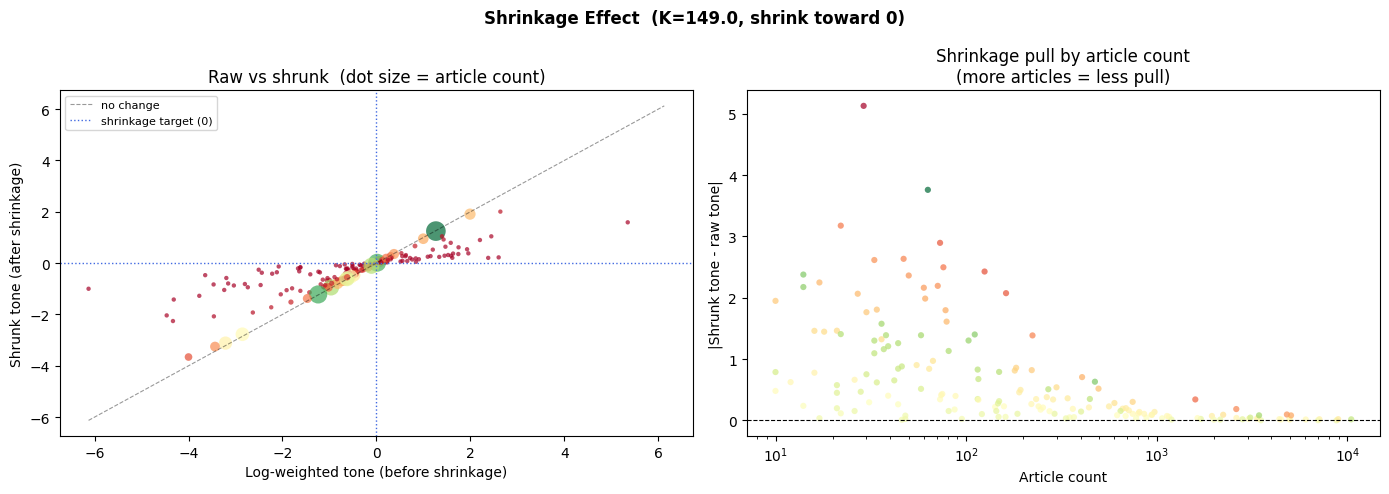

Mean absolute shrinkage pull : 0.6700
Max absolute shrinkage pull  : 5.1296  (BM)
Countries pulled > 0.5 tone  : 64


In [53]:
raw_log_weighted_tone = overall_grouped.apply(compute_log_weighted_average, include_groups=False).rename('raw_tone')
raw_counts            = overall_grouped['tone'].count().rename('raw_count')
comparison_dataframe  = pd.concat([raw_log_weighted_tone, raw_counts], axis=1)
comparison_dataframe  = comparison_dataframe.join(
    final_dataframe.set_index('primary_country_code')[['avg_tone', 'article_count']],
    how='inner',
)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
figure.suptitle(
    f'Shrinkage Effect  (K={shrinkage_k:.1f}, shrink toward 0)',
    fontsize=12, fontweight='bold',
)

axis_limit = max(
    abs(comparison_dataframe['raw_tone'].min()),
    abs(comparison_dataframe['raw_tone'].max()),
    5,
)
dot_sizes = np.clip(
    comparison_dataframe['article_count'] / comparison_dataframe['article_count'].max() * 200,
    10, 200,
)

axes[0].scatter(
    comparison_dataframe['raw_tone'],
    comparison_dataframe['avg_tone'],
    c=comparison_dataframe['article_count'],
    cmap='RdYlGn',
    s=dot_sizes,
    alpha=0.7,
    edgecolors='none',
)
axes[0].plot(
    [-axis_limit, axis_limit], [-axis_limit, axis_limit],
    'k--', linewidth=0.8, alpha=0.4, label='no change',
)
axes[0].axhline(0, color='royalblue', linestyle=':', linewidth=1, label='shrinkage target (0)')
axes[0].axvline(0, color='royalblue', linestyle=':', linewidth=1)
axes[0].set_xlabel('Log-weighted tone (before shrinkage)')
axes[0].set_ylabel('Shrunk tone (after shrinkage)')
axes[0].set_title('Raw vs shrunk  (dot size = article count)')
axes[0].legend(fontsize=8)

shrinkage_delta = (comparison_dataframe['avg_tone'] - comparison_dataframe['raw_tone']).abs()
axes[1].scatter(
    comparison_dataframe['article_count'],
    shrinkage_delta,
    c=comparison_dataframe['raw_tone'],
    cmap='RdYlGn',
    s=20,
    alpha=0.7,
    edgecolors='none',
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Article count')
axes[1].set_ylabel('|Shrunk tone - raw tone|')
axes[1].set_title('Shrinkage pull by article count\n(more articles = less pull)')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

print(f'Mean absolute shrinkage pull : {shrinkage_delta.mean():.4f}')
print(f'Max absolute shrinkage pull  : {shrinkage_delta.max():.4f}  ({shrinkage_delta.idxmax()})')
print(f'Countries pulled > 0.5 tone  : {(shrinkage_delta > 0.5).sum()}')

**#9a** - Tone scoring methods comparison

Compares 3 scoring methods side by side to show the effect of each pipeline design choice.
The airflow pipeline uses only the third stage.
1. Unweighted average
2. Log-weighted average
3. Log-weighted average with Bayesian shrinkage toward 0

Sorted by final shrunk tone so the most negative countries appear at the left.

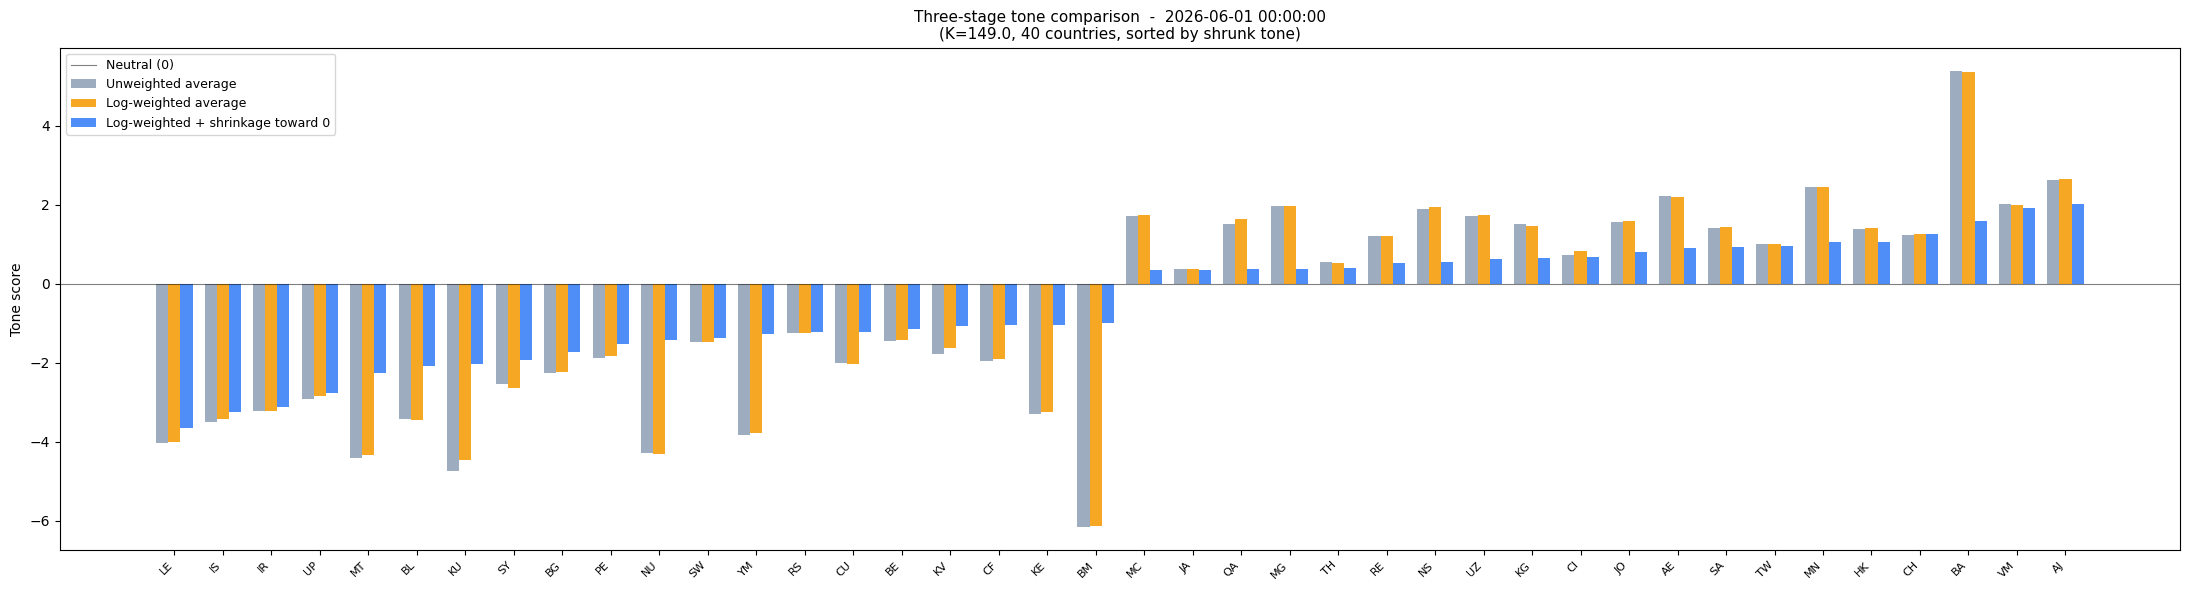

Countries shown : 40


In [54]:
COMPARE_TOP_N = 40   # how many countries to show (sorted by final shrunk tone)

plain_avg = (
    exploded_dataframe.groupby('primary_country_code')['tone']
    .mean()
    .rename('plain_avg_tone')
)

three_stage = (
    comparison_dataframe[['raw_tone', 'avg_tone', 'article_count']]
    .join(plain_avg, how='inner')
    .sort_values('avg_tone')
)

if len(three_stage) > COMPARE_TOP_N:
    three_stage = pd.concat([
        three_stage.head(COMPARE_TOP_N // 2),
        three_stage.tail(COMPARE_TOP_N // 2),
    ])

countries = three_stage.index.tolist()
x         = np.arange(len(countries))
bar_width = 0.25

figure, axis = plt.subplots(figsize=(max(14, len(countries) * 0.55), 6))

axis.bar(x - bar_width,     three_stage['plain_avg_tone'], bar_width, label='Unweighted average',               color='#94a3b8', alpha=0.9)
axis.bar(x,                 three_stage['raw_tone'],       bar_width, label='Log-weighted average',             color='#f59e0b', alpha=0.9)
axis.bar(x + bar_width,     three_stage['avg_tone'],       bar_width, label='Log-weighted + shrinkage toward 0', color='#3b82f6', alpha=0.9)

axis.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5, label='Neutral (0)')

axis.set_xticks(x)
axis.set_xticklabels(countries, rotation=45, ha='right', fontsize=8)
axis.set_ylabel('Tone score')
axis.set_title(
    f'Three-stage tone comparison  -  {TARGET_DATE}\n'
    f'(K={shrinkage_k:.1f}, {len(three_stage)} countries, sorted by shrunk tone)',
    fontsize=11,
)
axis.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Countries shown : {len(three_stage)}')

**#10** - Pipeline Summary

We track how many articles survive each stage of the pipeline. Any article that fails a step does not contribute to the final sentiment map.

In [60]:
post_word_count_filter = len(full_day_dataframe)
with_tone_data         = full_day_dataframe['tone'].notna().sum()
with_any_country       = full_day_dataframe['primary_country_codes'].apply(has_country_codes).sum()
with_category          = full_day_dataframe['article_category'].notna().sum()
after_tie_discard      = len(exploded_dataframe)
after_min_articles     = len(final_dataframe)

articles_in_final_countries = int(
    aggregated_dataframe[aggregated_dataframe['article_count'] >= MIN_ARTICLES]['article_count'].sum()
)
articles_dropped_with_small_countries = after_tie_discard - articles_in_final_countries

print(f'Pipeline Summary - {TARGET_DATE}')
print('=' * 70)
print()
print(f'  After word_count (>= {MIN_WORD_COUNT} filter)    : {post_word_count_filter:>8,}')
print(f'  With valid tone data                : {with_tone_data:>8,}  ({with_tone_data / post_word_count_filter * 100:6.2f}% of ingested)')
print(f'  With any country assigned           : {with_any_country:>8,}  ({with_any_country / post_word_count_filter * 100:6.2f}% of ingested)')
print(f'  With category classification        : {with_category:>8,}  ({with_category / post_word_count_filter * 100:6.2f}% of ingested)')
print()
print(f'  After tie discard (single-country)  : {after_tie_discard:>8,}  ({after_tie_discard / post_word_count_filter * 100:6.2f}%  of ingested)')
print(f'  Dropped with small countries        : {articles_dropped_with_small_countries:>8,}  (belonged to countries < {MIN_ARTICLES} articles)')
print(f'  Articles in final country_sentiment : {articles_in_final_countries:>8,} ')
print()
print(f'  Unique countries in final table     : {after_min_articles:>8,}  (>= {MIN_ARTICLES} articles per country)')

Pipeline Summary - 2026-06-01 00:00:00

  After word_count (>= 100 filter)    :  200,545
  With valid tone data                :  200,545  (100.00% of ingested)
  With any country assigned           :  162,497  (81.03% of ingested)
  With category classification        :   90,357  (45.06% of ingested)

  After tie discard (single-country)  :  150,599  (75.09%  of ingested)
  Dropped with small countries        :      160  (belonged to countries < 10 articles)
  Articles in final country_sentiment :  150,439 

  Unique countries in final table     :      165  (>= 10 articles per country)


---
## Section 6 - Article Inspector

Filter articles by category and country.
- Cell #12 re-classifies each article on the fly using the threshold constants in cell #11
- Changes to `CATEGORY_MINIMUM_PERCENTAGE`, `CATEGORY_MINIMUM_WINNING_GAP`, or `THEME_MINIMUM_HITS` take effect immediately after re-running cell #12; no re-ingest is required

**#11** - Query parameters

Change the flags below and re-run this cell followed by cell #12 to re-classify the article.

In [ ]:
CATEGORY_PRIORITY            = ['crime', 'health', 'politics', 'economy']
CATEGORY_MINIMUM_PERCENTAGE  = 50.0   # The winning category must have > CATEGORY_MINIMUM_PERCENTAGE % of all matched hits.
CATEGORY_MINIMUM_WINNING_GAP = 30.0   # The winning category must lead the runner-up by > CATEGORY_MINIMUM_WINNING_GAP percentage points.
TOP_THEMES                   = 8      # Number of top triggering themes displayed per category.

# The winning category must have >= THEME_MINIMUM_HITS[category] hits.
THEME_MINIMUM_HITS = {
    'crime':    3,
    'health':   3,
    'politics': 3,
    'economy':  3,
}

QUERY_POLITICS  = False     # include politics articles
QUERY_ECONOMY   = True      # include economy articles
QUERY_HEALTH    = False     # include health articles
QUERY_CRIME     = False     # include crime articles

QUERY_COUNTRY               = 'US'  # FIPS code e.g. 'TH', 'US'. Empty = all countries.
TOP_N                       = 30    # Maximum number of articles to display.
SORT_MOST_POSITIVE_FIRST    = True  # True = most positive first; False = most negative first.
SHOW_THEMES                 = True  # Show top triggering themes for each article.
SHOW_LOCATIONS              = True  # Show parsed location details for each article.
SHOW_RAW                    = True  # Show raw ENHANCEDLOCATIONS and ENHANCEDTHEMES values.

**#12** - Query results

For each matching article, the output shows:
- tone and assigned country
- raw location and theme fields
- which themes triggered the winning category

In [64]:
query_category_map = {
    'politics': QUERY_POLITICS,
    'economy':  QUERY_ECONOMY,
    'health':   QUERY_HEALTH,
    'crime':    QUERY_CRIME,
}
query_categories = [
    cat
    for cat, enabled in query_category_map.items()
    if enabled
]

if not query_categories:
    print('No category selected - set at least one QUERY_* = True in cell #11')
else:
    query_classified = full_day_dataframe['ENHANCEDTHEMES'].apply(classify_article_category_by_theme)
    mask = query_classified.isin(query_categories)

    if QUERY_COUNTRY:
        def country_in_codes(codes):
            return codes is not None and hasattr(codes, '__contains__') and QUERY_COUNTRY in codes

        mask &= full_day_dataframe['primary_country_codes'].apply(country_in_codes)

    results = full_day_dataframe[mask].copy()
    results['query_category'] = query_classified[mask]
    results = results.sort_values('tone', ascending=not SORT_MOST_POSITIVE_FIRST)

    category_label = ' | '.join(query_categories)
    country_label  = QUERY_COUNTRY if QUERY_COUNTRY else 'ALL'
    sort_label     = 'most positive first' if SORT_MOST_POSITIVE_FIRST else 'most negative first'

    print(f'Category    : {category_label}')
    print(f'Country     : {country_label}')
    print(f'Sort        : {sort_label}')
    print(f'Matched     : {len(results):,} / {len(full_day_dataframe):,}')
    print(f'Thresholds  : min_pct={CATEGORY_MINIMUM_PERCENTAGE}  min_gap={CATEGORY_MINIMUM_WINNING_GAP}  min_hits={THEME_MINIMUM_HITS}')
    print()

    if len(query_categories) > 1:
        print('Breakdown by category:')
        for category in query_categories:
            category_count = (results['query_category'] == category).sum()
            print(f'  {category:<12} {category_count:>6,}')
        print()

    LOCATION_TYPE_LABEL = {
        '1': 'COUNTRY', '2': 'USSTATE', '3': 'USCITY',
        '4': 'WORLDCITY', '5': 'WORLDSTATE',
    }

    def sort_theme_hits_descending(theme_count_pair):
        return -theme_count_pair[1]

    for display_index, (_, row) in enumerate(results.head(TOP_N).iterrows(), start=1):
        tone_str = f'{row["tone"]:+.2f}' if pd.notna(row['tone']) else '  N/A'
        assigned = row['primary_country_codes'] if row['primary_country_codes'] else []
        country  = assigned[0] if assigned else 'N/A'
        source   = str(row['SOURCECOMMONNAME'])[:28] if pd.notna(row['SOURCECOMMONNAME']) else 'N/A'
        url      = str(row['DOCUMENTIDENTIFIER'])
        print(f'[{display_index}] {str(row["query_category"]):<10}  {tone_str}  [{country}]  {source}')
        print(f'     {url}')

        locations      = parse_locations(row['ENHANCEDLOCATIONS'])
        country_counts = Counter(
            loc['location_country_code'] for loc in locations if loc['location_country_code']
        )
        location_summary = '  '.join(
            f'{code}x{count}' for code, count in country_counts.most_common()
        )
        if not country_counts:
            print('     country : unassigned  [no location data]')
        elif len(assigned) == 1:
            print(f'     country : winner ({location_summary})')
        else:
            print(f'     country : tied ({location_summary}) -> all: {", ".join(assigned)}')

        if SHOW_RAW:
            raw_loc = str(row['ENHANCEDLOCATIONS']) if pd.notna(row['ENHANCEDLOCATIONS']) else 'N/A'
            raw_thm = str(row['ENHANCEDTHEMES'])    if pd.notna(row['ENHANCEDTHEMES'])    else 'N/A'
            print(f'     RAW LOCATIONS : {raw_loc}')
            print(f'     RAW THEMES    : {raw_thm}')

        if SHOW_LOCATIONS and locations:
            print(f'     locations ({len(locations)}):')
            for loc in locations:
                type_label = LOCATION_TYPE_LABEL.get(str(loc['location_type']), loc['location_type'])
                print(f'       [{loc["location_country_code"]:>2}] {type_label:<10}  {loc["location_fullname"]}')

        if SHOW_THEMES:
            theme_entries = parse_enhanced_field(row['ENHANCEDTHEMES'])
            theme_hits    = {}
            for theme, _ in theme_entries:
                theme_hits[theme] = theme_hits.get(theme, 0) + 1

            category_hits = {}
            for theme, hit_count in theme_hits.items():
                for matched_category in get_matching_categories_for_theme(theme):
                    category_hits.setdefault(matched_category, []).append((theme, hit_count))

            category_totals = {
                cat: sum(count for _, count in themes)
                for cat, themes in category_hits.items()
            }
            grand_total = sum(category_totals.values())

            summary_parts = []
            for cat in CATEGORY_PRIORITY:
                total = category_totals.get(cat, 0)
                if total:
                    pct_val = total / grand_total * 100 if grand_total else 0
                    summary_parts.append(f'{cat}:{total}({pct_val:.0f}%)')
            print(f'     themes -> {" | ".join(summary_parts)}')

            winning_category = str(row['query_category'])
            top_themes = sorted(
                category_hits.get(winning_category, []),
                key=sort_theme_hits_descending,
            )[:TOP_THEMES]
            for theme, hit_count in top_themes:
                count_str = f' x{hit_count}' if hit_count > 1 else ''
                print(f'       [{winning_category[:3].upper()}] {theme}{count_str}')

        print()

Category    : economy
Country     : US
Sort        : most positive first
Matched     : 1,657 / 200,545
Thresholds  : min_pct=50.0  min_gap=30.0  min_hits={'crime': 3, 'health': 3, 'politics': 3, 'economy': 3}

[1] economy     +10.20  [US]  ksta.de
     https://www.ksta.de:443/shoppingwelt/skechers-sneaker-amazon-sale-schuhe-sparen-deals-angebote-rabatte-reduziert-131-860914
     country : winner (USx1)
     RAW LOCATIONS : 2#California, United States#US#USCA##36.17#-119.746#CA#1707
     RAW THEMES    : TAX_ECON_PRICE,6;TAX_ECON_PRICE,391;TAX_ECON_PRICE,827;TAX_ECON_PRICE,1868;TAX_FNCACT_WOMEN,277;TAX_FNCACT_WOMEN,1033;TAX_FNCACT_WOMEN,1054;TAX_FNCACT_WOMEN,1213;TAX_FNCACT_WOMEN,1224;TAX_FNCACT_WOMEN,1240;TAX_FNCACT_WOMEN,1251;TAX_FNCACT_WOMEN,1278;WB_644_NUTRITION,612;WB_644_NUTRITION,3021;WB_1441_SUPPLEMENTS,612;WB_1441_SUPPLEMENTS,3021;WB_621_HEALTH_NUTRITION_AND_POPULATION,612;WB_621_HEALTH_NUTRITION_AND_POPULATION,3021;
     locations (1):
       [US] USSTATE     California, United